In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
file_path = "https://raw.githubusercontent.com/naimdotcom/Machine-Learning/main/data/GDSC2_fitted_dose_response_27Oct23.csv"
df = pd.read_csv(file_path)
display(df.head())

,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,343,15946310,PFSK-1,SIDM01132,Other Solid Cancers,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-1.463887,0.930220,0.089052,0.433123
1,GDSC2,343,15946548,A673,SIDM00848,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-4.869455,0.614970,0.111351,-1.421100
2,GDSC2,343,15946830,ES5,SIDM00263,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.360586,0.791072,0.142855,-0.599569
3,GDSC2,343,15947087,ES7,SIDM00269,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-5.044940,0.592660,0.135539,-1.516647
4,GDSC2,343,15947369,EW-11,SIDM00203,Ewing's Sarcoma,1003,Camptothecin,TOP1,DNA replication,0.0001,0.1,-3.741991,0.734047,0.128059,-0.807232


In [ ]:
print(df.shape)

(242036, 16)


In [ ]:
df.isnull().sum()

,0
DATASET,0
NLME_RESULT_ID,0
NLME_CURVE_ID,0
CELL_LINE_NAME,0
SANGER_MODEL_ID,0
CANCER_TYPE,0
DRUG_ID,0
DRUG_NAME,0
PUTATIVE_TARGET,27155
PATHWAY_NAME,0


In [ ]:
def regression(x,w,b):
  return np.dot(x, w) + b

In [ ]:
def compute_gradient(x,y,w,b):
  fw_b=regression(x,w,b)
  m = x.shape[0]
  err=(fw_b - y)
  dj_w = np.dot(x.T,err)/m
  dj_b = np.sum(err)/m
  dj_w = np.clip(dj_w, -1e9, 1e9)
  dj_b = np.clip(dj_b, -1e9, 1e9)
  return dj_w,dj_b

In [ ]:
def compute_cost(x,y,w,b):
  m=x.shape[0]
  fw_b = regression(x,w,b)
  cost = np.sum((fw_b - y)**2)/(2*m)
  return cost

In [ ]:
def gradient_descent(x,y,alp=0.00001, iteration=1000):
  w,b=np.zeros(x.shape[1]),0
  cost_history=[]
  for i in range(iteration):
    dj_w,dj_b=compute_gradient(x,y,w,b)
    w = w - alp*dj_w
    b = b - alp*dj_b
    cost = compute_cost(x,y,w,b)
    cost_history.append(cost)
    if i % 1000 == 0:
      print(f"Iteration {i:6d} | Cost: {cost:.6f}")
  return w,b,cost_history


In [ ]:
def z_score(x):
  avg = np.mean(x)
  std = np.std(x)
  return (x-avg)/std

In [ ]:
df["MAX_CONC"] = z_score(df["MAX_CONC"])
df["MIN_CONC"] = z_score(df["MIN_CONC"])
df["LN_IC50"] = z_score(df["LN_IC50"])

In [ ]:
x = df[["MIN_CONC","MAX_CONC"]]
y = df["LN_IC50"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(193628, 2) (48408, 2) (193628,) (48408,)


In [ ]:
w_final, b_final, cost_history = gradient_descent(x_train, y_train)
print(w_final, b_final, cost_history)

[0.00246748 0.00247296] -1.664445508360763e-06 [np.float64(0.49945938360523745), np.float64(0.4994581386951025), np.float64(0.4994568938347367), np.float64(0.49945564902413786), np.float64(0.4994544042633046), np.float64(0.499453159552234), np.float64(0.499451914890925), np.float64(0.49945067027937495), np.float64(0.49944942571758233), np.float64(0.4994481812055447), np.float64(0.4994469367432605), np.float64(0.49944569233072733), np.float64(0.49944444796794357), np.float64(0.49944320365490685), np.float64(0.4994419593916157), np.float64(0.4994407151780676), np.float64(0.4994394710142609), np.float64(0.4994382269001934), np.float64(0.49943698283586335), np.float64(0.49943573882126846), np.float64(0.4994344948564072), np.float64(0.4994332509412771), np.float64(0.4994320070758762), np.float64(0.49943076326020297), np.float64(0.49942951949425496), np.float64(0.4994282757780304), np.float64(0.4994270321115272), np.float64(0.49942578849474345), np.float64(0.4994245449276772), np.float64(0.4

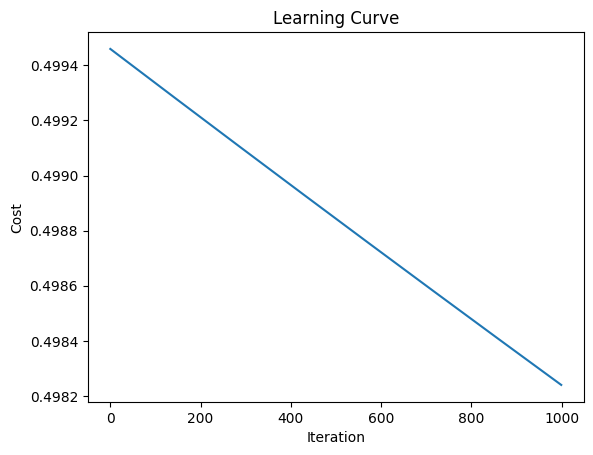

In [ ]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Learning Curve")
plt.show()